# Business Case: User Retention & Revenue Analysis

## Objective
Analyze user behavior, retention, and revenue patterns to identify:
- key drivers of retention
- differences between user segments
- opportunities to improve monetization

## Dataset
Synthetic dataset simulating a SaaS product with:
- users
- subscriptions
- usage
- daily metrics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DB_PATH = "/content/drive/MyDrive/Kalina_LucidLink_Assignment/gogosync_analytics.db"

conn = sqlite3.connect(DB_PATH)

def q(sql):
    return pd.read_sql_query(sql, conn)

# Task 1: SQL

## Query 1: Retrieve all enterprise users who signed up in 2024

In [ ]:
q("""
SELECT user_id, signup_date, country, account_status
FROM users
WHERE
    signup_date BETWEEN '2024-01-01' AND '2024-12-31'
    AND
    user_segment = 'enterprise'
ORDER BY signup_date ASC
;""")

,user_id,signup_date,country,account_status
0,454,2024-01-07,UK,active
1,472,2024-01-10,UK,active
2,474,2024-01-19,IT,active
3,499,2024-01-20,US,active
4,518,2024-01-24,ES,active
5,485,2024-01-29,UK,active
6,497,2024-01-30,IT,churned
7,488,2024-02-21,UK,active
8,513,2024-03-09,DE,active
9,531,2024-03-15,US,active


## Query 2: Calculate total MRR by plan type and user segment for currently active subscriptions

In [ ]:
q("""
SELECT
    s.plan_type,
    u.user_segment,
    SUM(s.mrr) AS total_mrr

FROM subscriptions AS s

INNER JOIN users AS u
    ON u.user_id = s.user_id

WHERE s.end_date IS NULL

GROUP BY s.plan_type, u.user_segment

ORDER BY total_mrr DESC

;""")

,plan_type,user_segment,total_mrr
0,enterprise,enterprise,14000
1,pro,team,7550
2,pro,individual,5500
3,basic,individual,1550
4,basic,team,1450
5,pro,enterprise,1050
6,free,individual,0


## Query 3: Query 3: Identify user segments with above-average spending on active subscriptions

In [ ]:
q("""
WITH overall AS (
    SELECT AVG(mrr) AS overall_avg_mrr
    FROM subscriptions
    WHERE end_date IS NULL
)

SELECT
    u.user_segment,
    AVG(s.mrr) AS avg_mrr_per_segment,
    COUNT(DISTINCT s.user_id) AS user_count,
    o.overall_avg_mrr

FROM subscriptions s

JOIN users u
  ON s.user_id = u.user_id

CROSS JOIN overall o
WHERE s.end_date IS NULL

GROUP BY u.user_segment

HAVING AVG(s.mrr) > o.overall_avg_mrr

ORDER BY avg_mrr_per_segment DESC;
""")

,user_segment,avg_mrr_per_segment,user_count,overall_avg_mrr
0,enterprise,165.384615,91,34.063527


## Query 4: Find the top 3 users by total GB transferred per country for the most recent month

In [ ]:
q("""

WITH

params AS (
  SELECT
    MAX(date) AS max_date,
    date(MAX(date), 'start of month') AS month_start,
    date(MAX(date), 'start of month', '+1 month') AS next_month_start,
    strftime('%Y-%m', MAX(date)) AS analysis_month
  FROM daily_usage
),

user_monthly AS (
  SELECT
    u.country,
    du.user_id,
    SUM(du.gb_transferred) AS total_gb_transferred
  FROM daily_usage du
  JOIN users u ON u.user_id = du.user_id
  JOIN params p
  WHERE du.date >= p.month_start
    AND du.date <  p.next_month_start
  GROUP BY u.country, du.user_id
),

ranked AS (
  SELECT
    country,
    user_id,
    total_gb_transferred,
    ROW_NUMBER() OVER (
      PARTITION BY country
      ORDER BY total_gb_transferred DESC
    ) AS rank_in_country
  FROM user_monthly
)

SELECT
  r.country,
  r.user_id,
  r.total_gb_transferred,
  r.rank_in_country,
  p.analysis_month
FROM ranked r
CROSS JOIN params p
WHERE r.rank_in_country <= 3
ORDER BY r.country, r.rank_in_country;""")

,country,user_id,total_gb_transferred,rank_in_country,analysis_month
0,AU,402,115.23,1,2025-12
1,AU,90,102.67,2,2025-12
2,AU,351,99.07,3,2025-12
3,CA,44,148.97,1,2025-12
4,CA,362,134.84,2,2025-12
5,CA,706,102.42,3,2025-12
6,DE,925,209.95,1,2025-12
7,DE,585,136.12,2,2025-12
8,DE,569,123.47,3,2025-12
9,ES,226,303.71,1,2025-12


# Task 2: Analytics Deep Dive

## Task 2.1: Analyze the distribution of total GB transferred by user segment

In [ ]:
# Combine user_segment and gb_transferred data

user_gb = q("""
    SELECT
        du.user_id,
        SUM(du.gb_transferred) AS total_gb_transferred
    FROM daily_usage du
    GROUP BY du.user_id
""")

users = q("""
    SELECT user_id, user_segment
    FROM users
""")

user_data = user_gb.merge(users, on="user_id", how="left")

user_data.head()

,user_id,total_gb_transferred,user_segment
0,1,1345.79,individual
1,2,1148.16,individual
2,3,1102.17,team
3,4,1412.78,team
4,5,1452.58,team


In [ ]:
user_data.groupby("user_segment")["total_gb_transferred"].describe()

,count,mean,std,min,25%,50%,75%,max
user_segment,,,,,,,,
enterprise,97.0,817.636701,390.379036,28.90,525.42,826.190,1102.550,1754.87
individual,573.0,810.692688,416.675340,5.02,464.31,851.360,1129.890,2132.26
team,324.0,822.652685,435.642115,16.35,484.16,866.005,1174.645,2203.22


In [ ]:
user_data.groupby("user_segment")["total_gb_transferred"].skew()

,total_gb_transferred
user_segment,
enterprise,0.166185
individual,-0.069128
team,-0.067280


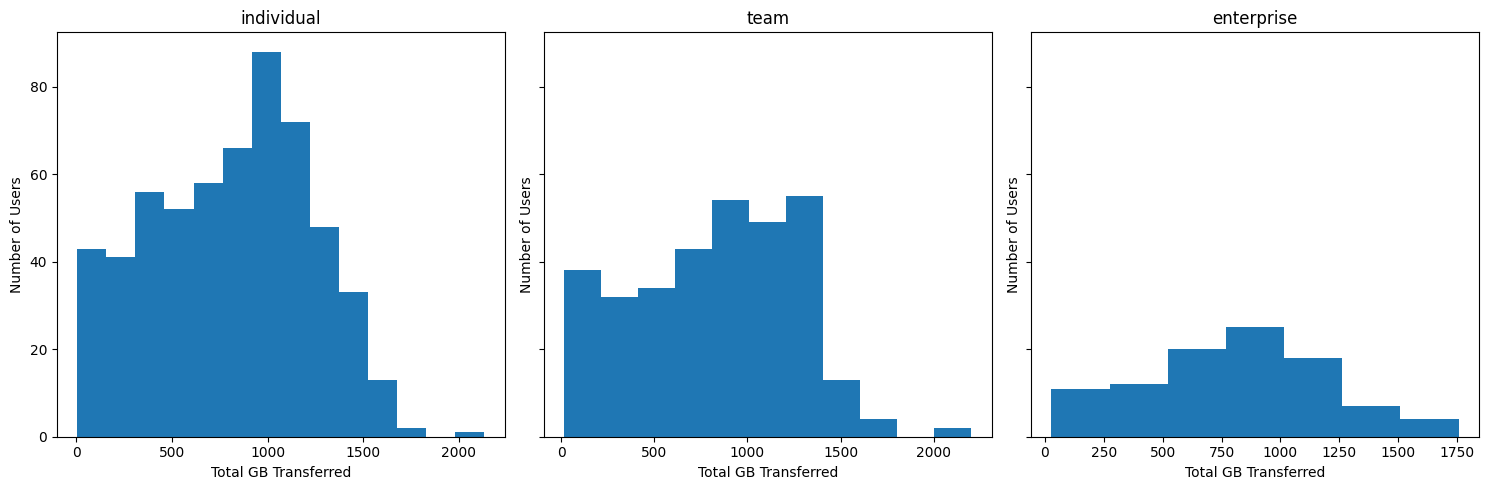

In [ ]:
# Histigram with distribution

segments = user_data["user_segment"].unique()

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

for ax, segment in zip(axes, segments):
    subset = user_data[user_data["user_segment"] == segment]
    ax.hist(subset["total_gb_transferred"], bins= "fd") # bin numbers adapts to the sample size
    ax.set_title(segment)
    ax.set_xlabel("Total GB Transferred")
    ax.set_ylabel("Number of Users")

plt.tight_layout()
plt.show()

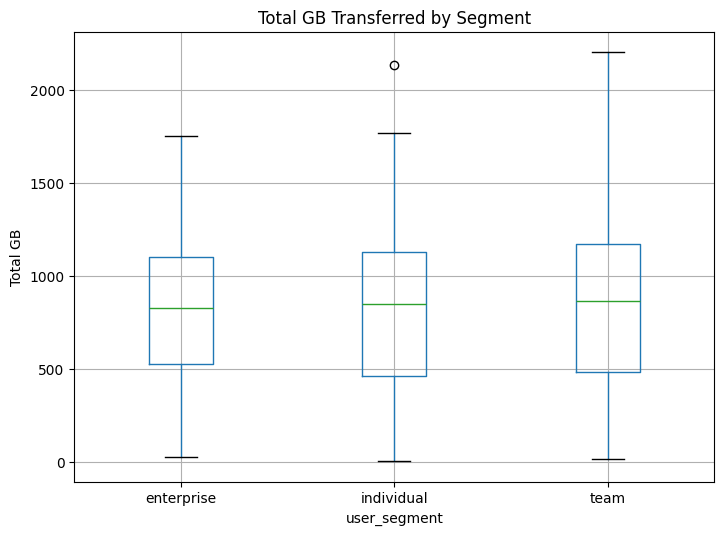

In [ ]:
# Boxplot

user_data.boxplot(column="total_gb_transferred", by="user_segment", figsize=(8,6))
plt.title("Total GB Transferred by Segment")
plt.suptitle("")
plt.ylabel("Total GB")
plt.show()

### Key Insights

Summary of insights:
* All three segments show approximately symmetric distributions.
* Skewness is minimal.
* Means and medians are nearly identical.
* Central tendency is similar across segments (810–870 GB).
* Dispersion is also similar (std 390–435).

Interpretation:
* Usage behavior is similar across segments.
* Enterprise users are not transferring dramatically more data than individual users.
* Behavioral patterns are not the primary driver of segmentation.
* The revenue differentiation could reflect willingness to pay for governance, reliability, dealing with organizational complexity.

## Task 2.2: Compare MRR metrics across user segments

In [ ]:
# Get suscriptions data

subs = q("""
    SELECT
        s.subscription_id,
        s.user_id,
        s.plan_type,
        s.mrr,
        s.start_date,
        s.end_date,
        u.user_segment
    FROM subscriptions s
    JOIN users u
        ON s.user_id = u.user_id
""")

subs.head()

,subscription_id,user_id,plan_type,mrr,start_date,end_date,user_segment
0,1,1,free,0,2023-06-06,None,individual
1,2,2,free,0,2023-06-19,None,individual
2,3,3,basic,10,2023-05-28,None,team
3,4,4,basic,10,2023-05-14,2025-01-09,team
4,5,4,pro,50,2025-01-09,None,team


In [ ]:
from datetime import datetime

In [ ]:
# Convert to datetime
subs["start_date"] = pd.to_datetime(subs["start_date"])
subs["end_date"] = pd.to_datetime(subs["end_date"])

# Use today's date for active subscriptions
today = pd.Timestamp.today().normalize()

subs["effective_end"] = subs["end_date"].fillna(today)

subs["tenure_days"] = (subs["effective_end"] - subs["start_date"]).dt.days

subs.head()

,subscription_id,user_id,plan_type,mrr,start_date,end_date,user_segment,effective_end,tenure_days
0,1,1,free,0,2023-06-06,NaT,individual,2026-02-26,996
1,2,2,free,0,2023-06-19,NaT,individual,2026-02-26,983
2,3,3,basic,10,2023-05-28,NaT,team,2026-02-26,1005
3,4,4,basic,10,2023-05-14,2025-01-09,team,2025-01-09,606
4,5,4,pro,50,2025-01-09,NaT,team,2026-02-26,413


In [ ]:
# Calculate median MRR by user segment

median_mrr = (
    subs.groupby("user_segment")["mrr"]
    .median()
    .reset_index(name="median_mrr")
)

median_mrr

,user_segment,median_mrr
0,enterprise,200.0
1,individual,0.0
2,team,10.0


In [ ]:
# Calculate the weighted average: sum(MRR * Tenure Days) / sum(Tenure days)

weighted_avg = (
    subs.groupby("user_segment")
        .apply(lambda x: (x["mrr"] * x["tenure_days"]).sum() / x["tenure_days"].sum())
        .reset_index(name="weighted_avg_mrr")
)

weighted_avg["weighted_avg_mrr"] = weighted_avg["weighted_avg_mrr"].round(2)

weighted_avg

/tmp/ipython-input-1027/859450772.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["mrr"] * x["tenure_days"]).sum() / x["tenure_days"].sum())


,user_segment,weighted_avg_mrr
0,enterprise,154.59
1,individual,11.44
2,team,28.32


In [ ]:
# Compare median mrr vs weighted average mrr

comparison = median_mrr.merge(weighted_avg, on="user_segment")
comparison

,user_segment,median_mrr,weighted_avg_mrr
0,enterprise,200.0,154.59
1,individual,0.0,11.44
2,team,10.0,28.32


### Conclusion

- While usage intensity is similar across segments (Task 2.1), revenue differs substantially, particularly for enterprise users.
- The tenure-weighted average MRR better reflects economic value because it incorporates retention and long-term revenue contribution.
- Enterprise remains the most economically valuable segment, but team users show stronger long-term revenue than median pricing suggests.

## Task 2.3: Evaluate two user groups and recommend which performs better

In [ ]:
cohorts = q("""
    SELECT
        user_id,
        test_group,
        adoption_intensity
    FROM user_cohorts
""")

# checks
print(cohorts.shape)
print(cohorts["test_group"].value_counts())
cohorts.head()

(500, 3)
test_group
B    254
A    246
Name: count, dtype: int64


,user_id,test_group,adoption_intensity
0,1000,A,86
1,994,B,60
2,999,A,52
3,998,B,50
4,993,B,32


In [ ]:
summary = cohorts.groupby("test_group")["adoption_intensity"].describe()

summary

,count,mean,std,min,25%,50%,75%,max
test_group,,,,,,,,
A,246.0,46.593496,27.977932,0.0,29.0,42.0,61.0,191.0
B,254.0,53.578740,17.200276,0.0,43.0,54.5,63.0,173.0


/tmp/ipython-input-1027/1414063558.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([


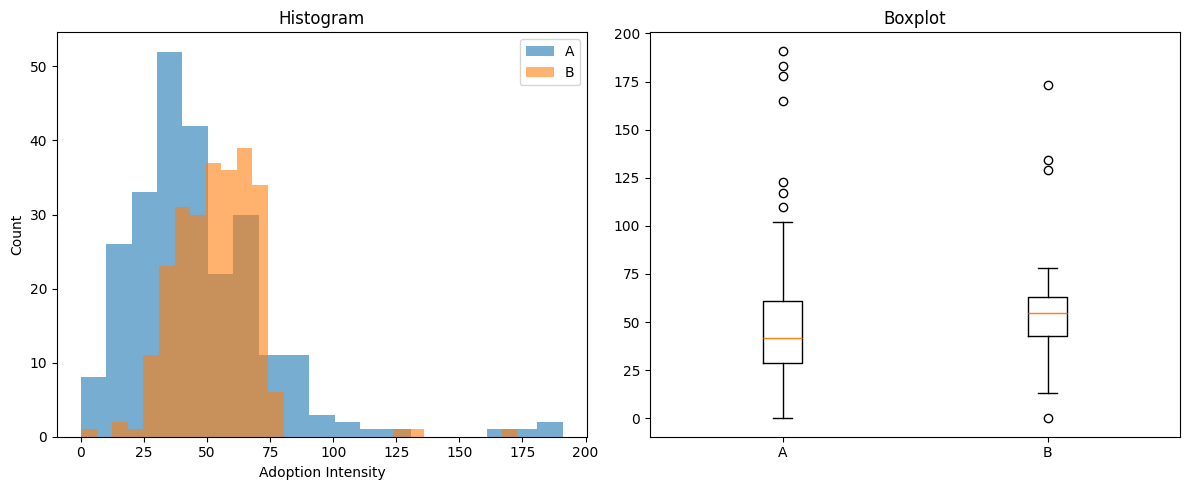

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
axes[0].hist(cohorts[cohorts["test_group"]=="A"]["adoption_intensity"],
             bins="fd", alpha=0.6, label="A")
axes[0].hist(cohorts[cohorts["test_group"]=="B"]["adoption_intensity"],
             bins="fd", alpha=0.6, label="B")
axes[0].set_title("Histogram")
axes[0].set_xlabel("Adoption Intensity")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
axes[1].boxplot([
    cohorts[cohorts["test_group"]=="A"]["adoption_intensity"],
    cohorts[cohorts["test_group"]=="B"]["adoption_intensity"]
], labels=["A", "B"])
axes[1].set_title("Boxplot")

plt.tight_layout()
plt.show()

Group A:

- Creates some very high adopters
- Has extreme users

Group B:

- Lifts the average user
- Increases median
- More consistent engagement


Group B seems to be the better onboarding approach. Will be validated with a stattistical test below.

Which test? n = 250 per group & skewed distribution -> Independent t-test (Welch's)

H0: There is no difference in average adoption intensity between onboarding approaches A and B.
Any observed difference is due to random variation.

In [ ]:
from scipy.stats import ttest_ind

a = cohorts[cohorts["test_group"] == "A"]["adoption_intensity"]
b = cohorts[cohorts["test_group"] == "B"]["adoption_intensity"]

ttest_ind(b, a, equal_var=False)

TtestResult(statistic=np.float64(3.3504269708046897), pvalue=np.float64(0.0008826476102267002), df=np.float64(404.68296684356096))

Conducted a Welch’s two-sample t-test to compare mean adoption intensity between Group A and Group B.
* Test statistic: t = 3.35
* p-value: 0.00088
* Since p < 0.05, we reject the null hypothesis.
* Conclusion: The difference in average adoption intensity between the two onboarding approaches is statistically significant.

In [ ]:
mean_diff = b.mean() - a.mean()
pooled_std = np.sqrt((a.var() + b.var()) / 2)
cohens_d = mean_diff / pooled_std
cohens_d

np.float64(0.3007900916972266)

Effect Size: Cohen’s d = 0.30
Interpretation:
* Indicates a small-to-moderate effect size
* The improvement is meaningful but not large

### Conclusion

Recommendation: Onboarding Approach B.
* Higher average engagement
* Higher typical (median) engagement
* More consistent behavior
* Statistically significant improvement

Trade-offs:
* Group A shows higher variability and produces some extreme high adopters (very high maximum values).
* If the goal were to maximize usage, A might have value.

# Task 3: Time Series Forecasting

In [ ]:
# Get daily_metrics
daily_metrics = q("""
SELECT *
FROM daily_metrics
ORDER BY date
""")

# Convert date column to datetime
daily_metrics["date"] = pd.to_datetime(daily_metrics["date"])

# Order by date
daily_metrics = daily_metrics.sort_values("date").reset_index(drop=True)

# Set date as index
daily_metrics = daily_metrics.set_index("date")

daily_metrics.head()

,daily_active_users,new_signups,total_gb_transferred,mrr_total
date,,,,
2023-01-01,669,0,0.0,4250.00
2023-01-02,870,0,0.0,4252.27
2023-01-03,823,0,0.0,4254.55
2023-01-04,812,0,0.0,4256.82
2023-01-05,810,0,0.0,4259.10


## Exploratory analysis

In [ ]:
daily_metrics.info()

daily_metrics.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1096 entries, 2023-01-01 to 2025-12-31
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   daily_active_users    1096 non-null   int64  
 1   new_signups           1096 non-null   int64  
 2   total_gb_transferred  1096 non-null   float64
 3   mrr_total             1096 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 42.8 KB


,daily_active_users,new_signups,total_gb_transferred,mrr_total
count,1096.000000,1096.000000,1096.000000,1096.000000
mean,1363.246350,0.912409,739.395201,7114.494644
std,402.573853,1.109359,452.963414,1897.091272
min,427.000000,0.000000,0.000000,4250.000000
25%,1061.750000,0.000000,420.340000,5513.235000
50%,1302.000000,1.000000,809.580000,6707.645000
75%,1598.000000,1.000000,1072.230000,8147.740000
max,3362.000000,7.000000,2358.860000,11673.070000


In [ ]:
# 1096 days are present - which includes all 3 years, so no missing dates

In [ ]:
# Add day of the week to dataframe + is_weekend check

daily_metrics["day_name"] = daily_metrics.index.day_name()
daily_metrics["is_weekend"] = daily_metrics.index.weekday >= 5

daily_metrics.head()

,daily_active_users,new_signups,total_gb_transferred,mrr_total,day_name,is_weekend
date,,,,,,
2023-01-01,669,0,0.0,4250.00,Sunday,True
2023-01-02,870,0,0.0,4252.27,Monday,False
2023-01-03,823,0,0.0,4254.55,Tuesday,False
2023-01-04,812,0,0.0,4256.82,Wednesday,False
2023-01-05,810,0,0.0,4259.10,Thursday,False


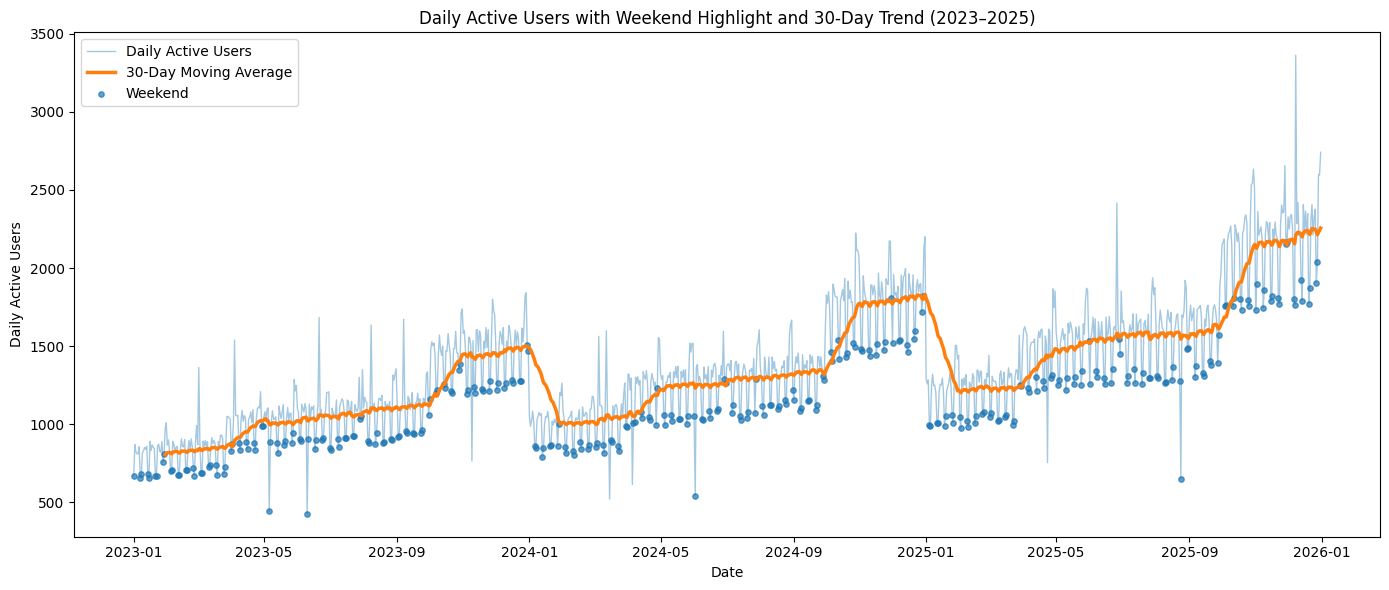

In [ ]:
#--- 30-day moving average ---
daily_metrics["dau_30d_ma"] = (
    daily_metrics["daily_active_users"]
    .rolling(window=30)
    .mean()
)

# --- Plot ---
plt.figure(figsize=(14, 6))

# Daily Active Users Data
plt.plot(
    daily_metrics.index,
    daily_metrics["daily_active_users"],
    alpha=0.4,
    linewidth=1,
    label="Daily Active Users"
)

# 30-day moving average
plt.plot(
    daily_metrics.index,
    daily_metrics["dau_30d_ma"],
    linewidth=2.5,
    label="30-Day Moving Average"
)

# Weekend points
weekends = daily_metrics[daily_metrics["is_weekend"]]

plt.scatter(
    weekends.index,
    weekends["daily_active_users"],
    s=15,
    alpha=0.7,
    label="Weekend"
)

plt.title("Daily Active Users with Weekend Highlight and 30-Day Trend (2023–2025)")
plt.xlabel("Date")
plt.ylabel("Daily Active Users")
plt.legend()
plt.tight_layout()
plt.show()

* Upward and stable trend
* Annual seasonality -> spikes at the end of the year followed by a dip at the beginning of the year
* Weekly seasonality -> Weekend DAU consistently lower

## Forecast:

The series shows sustained growth with stable weekly and annual calendar-driven seasonality. I therefore chose a regression model with a linear time trend and weekday and month fixed effects, which captures long-term growth and recurring patterns while remaining interpretable, robust, and appropriate for infrastructure capacity planning.

MAE:  111.04
RMSE: 174.05


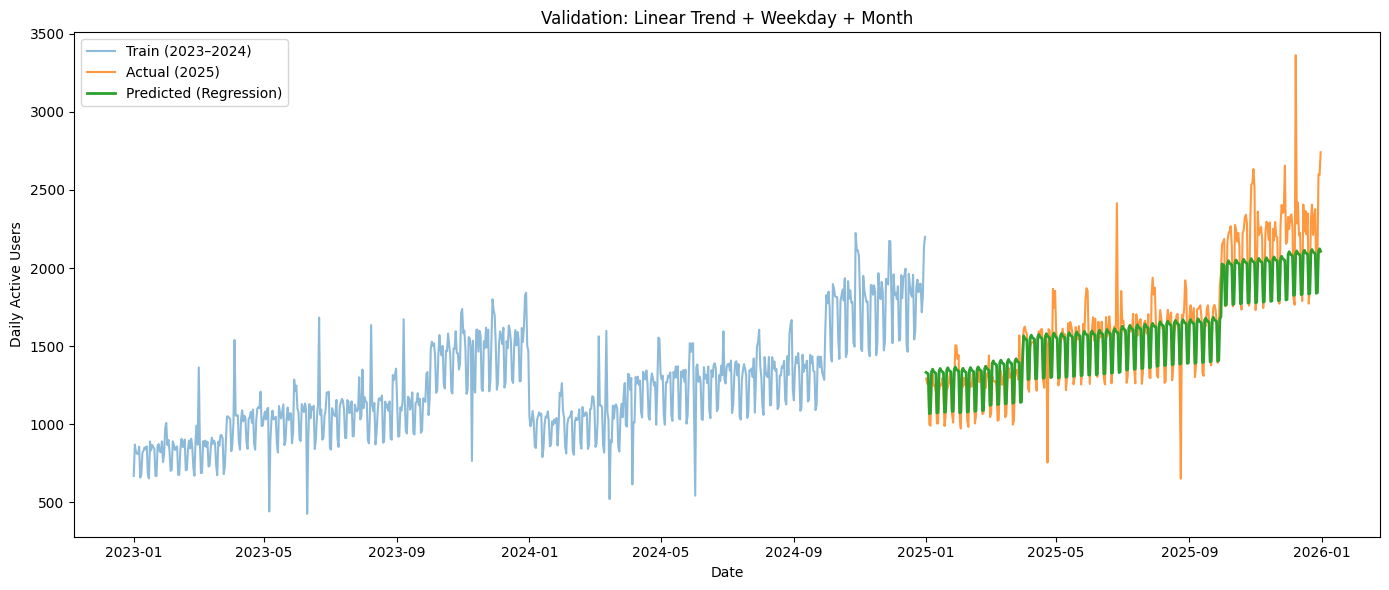

In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load daily_metrics
df = daily_metrics.copy()

# Sort datetime index
df = df.sort_index()

# Feature engineering
df["t"] = np.arange(len(df))                     # linear time trend
df["weekday"] = df.index.weekday                 # 0=Mon, 6=Sun
df["month"] = df.index.month                     # 1-12


#Train / Test split
train = df.loc[: "2024-12-31"].copy()
test  = df.loc["2025-01-01":].copy()

y_train = train["daily_active_users"]
y_test  = test["daily_active_users"]

# ----- TRAIN -----
X_train = train[["t"]].copy()

X_train = pd.concat([
    X_train,
    pd.get_dummies(train["weekday"], prefix="weekday", drop_first=True),
    pd.get_dummies(train["month"], prefix="month", drop_first=True)
], axis=1)

# ----- TEST -----
X_test = test[["t"]].copy()

X_test = pd.concat([
    X_test,
    pd.get_dummies(test["weekday"], prefix="weekday", drop_first=True),
    pd.get_dummies(test["month"], prefix="month", drop_first=True)
], axis=1)

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Add constant
X_train = sm.add_constant(X_train)
X_test  = sm.add_constant(X_test)

# Fit + predict - Ordinary Least Squares
model = sm.OLS(y_train.astype(float), X_train.astype(float)).fit()
pred_test = model.predict(X_test.astype(float))

# Metrics
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


#Plot predicted vs actual

plt.figure(figsize=(14,6))

plt.plot(y_train.index, y_train, label="Train (2023–2024)", alpha=0.5)
plt.plot(y_test.index, y_test, label="Actual (2025)", alpha=0.8)
plt.plot(y_test.index, pred_test, label="Predicted (Regression)", linewidth=2)

plt.title("Validation: Linear Trend + Weekday + Month")
plt.xlabel("Date")
plt.ylabel("Daily Active Users")
plt.legend()
plt.tight_layout()
plt.show()

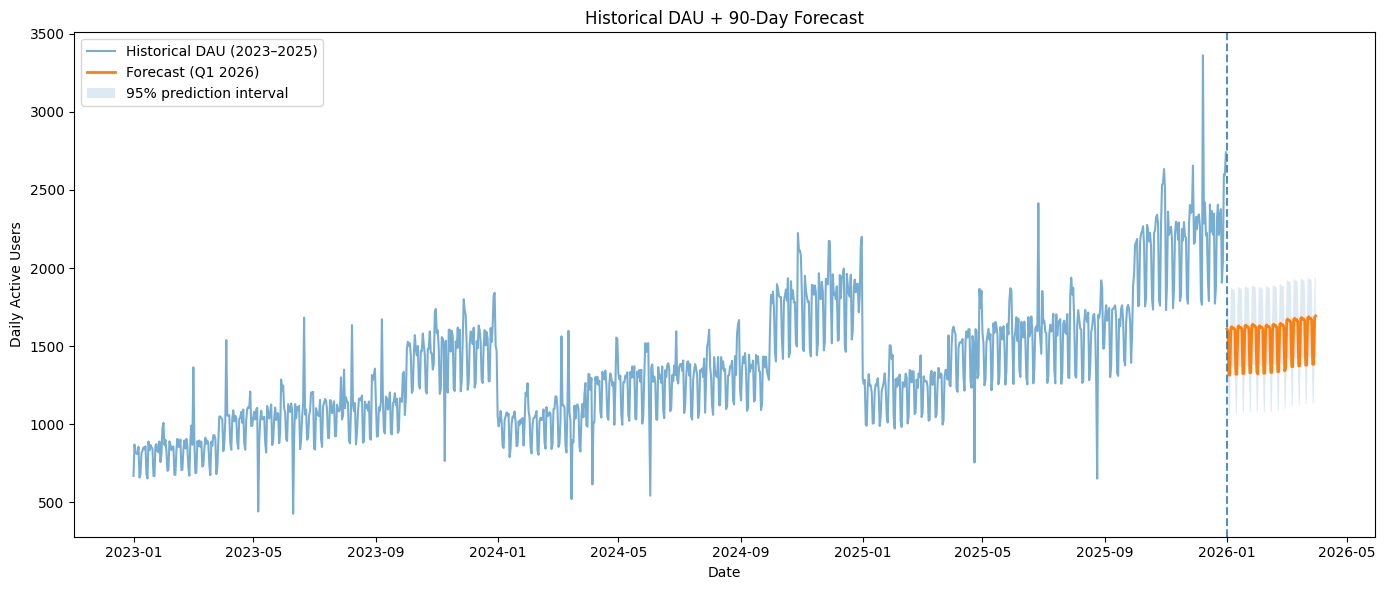

,predicted_dau,lower_95,upper_95
2026-01-01,1610.453731,1359.917375,1860.990087
2026-01-02,1600.065594,1349.527557,1850.603631
2026-01-03,1314.954773,1064.397636,1565.511910
2026-01-04,1315.361088,1064.818766,1565.903410
2026-01-05,1618.601615,1368.078145,1869.125086


In [ ]:
# Refit on full history (2023–2025), forecast Q1 2026 + 95% PI

# Refit model on full history
df_full = df.copy()

y_full = df_full["daily_active_users"].astype(float)

X_full = df_full[["t"]].copy()
X_full = pd.concat(
    [
        X_full,
        pd.get_dummies(df_full["weekday"], prefix="weekday", drop_first=True, dtype=int),
        pd.get_dummies(df_full["month"], prefix="month", drop_first=True, dtype=int),
    ],
    axis=1,
)

X_full = sm.add_constant(X_full, has_constant="add").astype(float)

final_model = sm.OLS(y_full, X_full).fit()


# Future dates (90 days)
future_dates = pd.date_range("2026-01-01", "2026-03-31", freq="D")
assert len(future_dates) == 90

future = pd.DataFrame(index=future_dates)
future["t"] = np.arange(len(df_full), len(df_full) + len(future_dates))
future["weekday"] = future.index.weekday
future["month"] = future.index.month


# Build X_future (same logic as training)
X_future = future[["t"]].copy()
X_future = pd.concat(
    [
        X_future,
        pd.get_dummies(future["weekday"], prefix="weekday", drop_first=True, dtype=int),
        pd.get_dummies(future["month"], prefix="month", drop_first=True, dtype=int),
    ],
    axis=1,
)

X_future = sm.add_constant(X_future, has_constant="add")

# Align columns
X_future = X_future.reindex(columns=final_model.model.exog_names, fill_value=0).astype(float)


# Forecast + 95% prediction interval
pred = final_model.get_prediction(X_future).summary_frame(alpha=0.05)

# pred has: mean, mean_se, mean_ci_lower/upper, obs_ci_lower/upper
forecast_df = pd.DataFrame(
    {
        "predicted_dau": pred["mean"].values,
        "lower_95": pred["obs_ci_lower"].values,
        "upper_95": pred["obs_ci_upper"].values,
    },
    index=future_dates,
)


# Plot historical + forecast + 95% PI
plt.figure(figsize=(14, 6))

plt.plot(df_full.index, df_full["daily_active_users"], label="Historical DAU (2023–2025)", alpha=0.6)
plt.plot(forecast_df.index, forecast_df["predicted_dau"], label="Forecast (Q1 2026)", linewidth=2)

plt.fill_between(
    forecast_df.index,
    forecast_df["lower_95"],
    forecast_df["upper_95"],
    alpha=0.15,
    label="95% prediction interval",
)

plt.axvline(pd.Timestamp("2026-01-01"), linestyle="--", alpha=0.8)
plt.title("Historical DAU + 90-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Daily Active Users")
plt.legend()
plt.tight_layout()
plt.show()

forecast_df.head()

## Business interpretation

Given the sustained linear growth trend and stable calendar-driven usage patterns, I implemented a regression model with a continuous time trend and weekday and month fixed effects. The model captures deterministic growth and recurring seasonal behavior while remaining interpretable and robust for operational planning.

The model projects average daily active users in Q1 2026 at approximately 1,600–1,650, gradually increasing through March following the historical recovery after early-January seasonality. The 95% prediction interval suggests daily usage is likely to range between roughly 1,350 and 1,950 users under normal operating conditions.

For infrastructure planning, systems should comfortably support at least 1,950 daily active users, with an additional 5–10% buffer (approximately 2,050–2,150 DAU) to mitigate upside growth risk.

Risks: The forecast assumes continued linear growth and stable calendar effects. It does not account for structural shifts such as major product launches, enterprise onboarding cycles, pricing changes, or demand shocks. Additionally, the January dip is based on limited historical observations. Forecasts should therefore be reviewed regularly and capacity buffers maintained above the projected upper bound.